# 01 — Gegnerstruktur

Frage: *Unterscheidet sich die Gegnerstruktur zwischen female_top (ELO 2400–2600) und male_control (age-matched)?*

Kennzahl: `avg_opponent_diff` = Ø Rating der Gegner − eigenes Rating pro Periode.

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_view, load_query, apply_style, GROUP_PALETTE, GROUP_ORDER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()

## Daten laden

In [4]:
df = load_view('v_opponent_strength')
df['period'] = pd.to_datetime(df['period'])
df[['avg_opponent_rating', 'avg_opponent_diff', 'own_rating']] = (
    df[['avg_opponent_rating', 'avg_opponent_diff', 'own_rating']].astype(float)
)
print(df.shape)
df.head()

(56172, 6)


,analysis_group,fide_id,period,own_rating,avg_opponent_rating,avg_opponent_diff
0,elite_2600,309095,2010-01-01,2692.0,2654.200000,-37.800000
1,elite_2600,309095,2010-05-01,2707.0,2563.708333,-143.291667
2,elite_2600,309095,2010-07-01,2718.0,2473.444444,-244.555556
3,elite_2600,309095,2010-09-01,2731.0,2563.428571,-167.571429
4,elite_2600,309095,2010-11-01,2731.0,2614.464286,-116.535714


## Summary pro Gruppe

In [5]:
summary = df.groupby('analysis_group').agg(
    n_player_periods=('fide_id', 'count'),
    n_players=('fide_id', 'nunique'),
    mean_opp_rating=('avg_opponent_rating', 'mean'),
    mean_opp_diff=('avg_opponent_diff', 'mean'),
    median_opp_diff=('avg_opponent_diff', 'median'),
).round(1)
summary

,n_player_periods,n_players,mean_opp_rating,mean_opp_diff,median_opp_diff
analysis_group,,,,,
elite_2600,15725,153,2459.4,-97.6,-98.8
female_2200,400,4,2154.4,-39.1,-38.7
female_top,3988,43,2278.6,-86.4,-93.6
male_control,36059,435,2287.9,-108.0,-113.0


## Boxplot — Ø Rating-Differenz pro Gruppe

Negative Werte = Gegner im Schnitt schwächer als man selbst.

/var/folders/3b/wd_8tgyj0x3d8fgs9v_jsn1m0000gn/T/ipykernel_97107/4058454371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


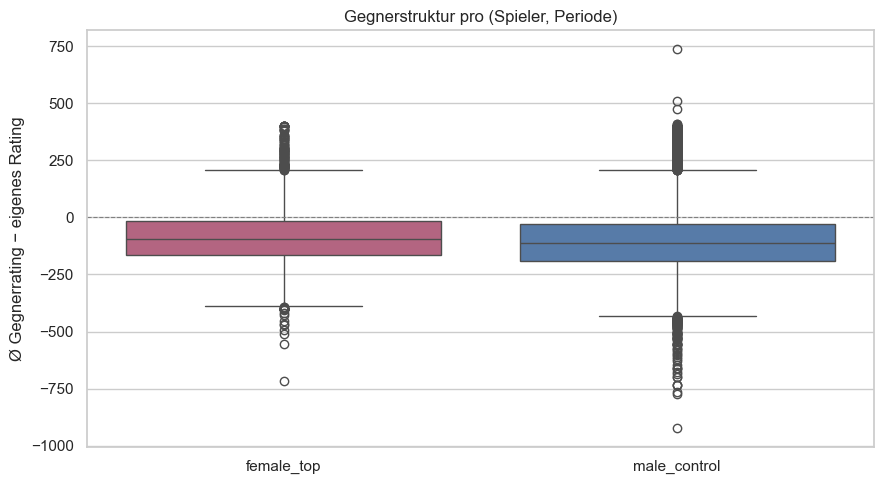

In [6]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, x='analysis_group', y='avg_opponent_diff',
    order=GROUP_ORDER, palette=GROUP_PALETTE, ax=ax,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Ø Gegnerrating − eigenes Rating')
ax.set_xlabel('')
ax.set_title('Gegnerstruktur pro (Spieler, Periode)')
plt.tight_layout(); plt.show()

## Verteilung der einzelnen Gegner-Ratings

Für einen direkten Histogramm-Vergleich gehen wir auf Einzelpartie-Ebene.

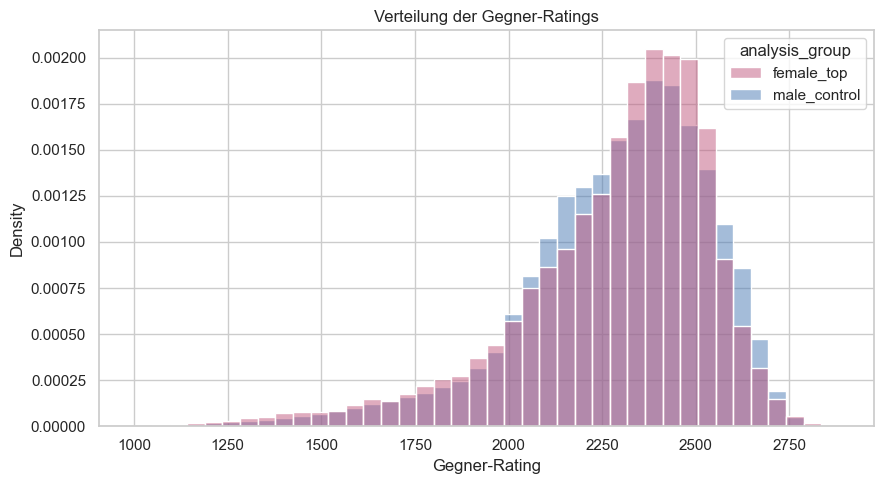

In [7]:
raw = load_query('''
    SELECT p.analysis_group, gr.opponent_rating
    FROM game_results gr
    JOIN players p USING (fide_id)
    WHERE p.active = TRUE AND p.analysis_group IS NOT NULL
      AND gr.opponent_rating IS NOT NULL
''')
fig, ax = plt.subplots()
sns.histplot(
    data=raw, x='opponent_rating', hue='analysis_group',
    bins=40, stat='density', common_norm=False,
    palette=GROUP_PALETTE, hue_order=GROUP_ORDER, ax=ax,
)
ax.set_xlabel('Gegner-Rating')
ax.set_title('Verteilung der Gegner-Ratings')
plt.tight_layout(); plt.show()